# MST construction and embedding runtime scaling

This notebook compares exact dense Prim and sparse approximate FAMST **MST graph construction** as the dataset grows. It also measures full t-SNE and UMAP embedding fits on the same synthetic datasets to provide runtime context. These are different workloads: MST timings exclude embedding optimization, while t-SNE and UMAP timings include a full embedding fit.

FAMST is approximate. Alongside wall-clock speedup, the notebook reports relative total tree-weight error against Prim wherever the exact run fits the configured memory budget. Install the benchmark dependencies with `python -m pip install -e ".[notebook,famst]"`. The import cell searches the current directory and its parents for the repository. If it cannot find it, install with `python -m pip install -e ".[famst]"` from the repository root.

The timings are machine- and environment-dependent. Warm-up runs for FAMST and UMAP are excluded. t-SNE and UMAP are benchmarked only up to `EMBEDDING_MAX_SAMPLES` to limit runtime.

In [1]:
from time import perf_counter
from pathlib import Path
import platform
import sys
from inspect import signature

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
import umap

# Jupyter may start the kernel in the repository root or its notebooks folder.
repo_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "imste" / "__init__.py").is_file()),
    None,
)
if repo_root is not None and str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

try:
    from imste.mst import build_mst_edges
except ModuleNotFoundError as exc:
    if exc.name != "imste" and not (exc.name or "").startswith("imste."):
        raise
    raise ModuleNotFoundError(
        "Could not locate the IMSTE package. Open this notebook from the "
        "repository, or install it with `python -m pip install -e '.[notebook,famst]'` "
        "from the repository root."
    ) from exc

print(f"Python: {platform.python_version()}")
print(f"NumPy: {np.__version__}")
print(f"scikit-learn: {__import__('sklearn').__version__}")
print(f"UMAP: {umap.__version__}")

Python: 3.12.13
NumPy: 2.5.3
scikit-learn: 1.9.1
UMAP: 0.5.12


## Benchmark settings

Increase `SAMPLE_SIZES` to explore larger inputs. Exact Prim is skipped when its estimated distance-matrix and packed-edge storage exceeds `EXACT_MEMORY_BUDGET_GB`; this is a guard estimate, not a system memory monitor. Keep `REPEATS` small for larger sizes because exact Prim has quadratic cost. t-SNE and UMAP use the same synthetic inputs, but are capped at `EMBEDDING_MAX_SAMPLES` because each run performs a full embedding fit.

In [2]:
SAMPLE_SIZES = [128, 256, 512, 1_024, 2_048, 4_096, 8_192, 16_384, 30_000, 60_000]
N_FEATURES = 32
N_MSTS = 1
ANN_NEIGHBORS = 15
INTER_COMPONENT_EDGES = 5
MAX_ANN_NEIGHBORS = 60
REPEATS = 2
DATA_SEED = 42
BENCHMARK_SEED = 123
EXACT_MEMORY_BUDGET_GB = 1.0
EMBEDDING_MAX_SAMPLES = 8_192
TSNE_ITERATIONS = 1_000
UMAP_NEIGHBORS = 15

TSNE_ITERATION_PARAMETER = (
    'max_iter' if 'max_iter' in signature(TSNE).parameters else 'n_iter'
)

def make_tsne(random_state):
    return TSNE(
        n_components=2,
        init='pca',
        learning_rate='auto',
        method='barnes_hut',
        random_state=random_state,
        **{TSNE_ITERATION_PARAMETER: TSNE_ITERATIONS},
    )

def estimated_prim_graph_bytes(n_samples):
    # float64 pairwise distances plus the packed edge-availability matrix.
    return n_samples**2 * (8 + 1 / 8)

pd.DataFrame({
    'n_samples': SAMPLE_SIZES,
    'estimated_exact_graph_memory_mb': [
        estimated_prim_graph_bytes(n) / 1024**2 for n in SAMPLE_SIZES
    ],
})

,n_samples,estimated_exact_graph_memory_mb
0,128,0.126953
1,256,0.507812
2,512,2.031250
3,1024,8.125000
4,2048,32.500000
5,4096,130.000000
6,8192,520.000000
7,16384,2080.000000
8,30000,6973.743439
9,60000,27894.973755


## Warm up the backends

FAMST uses PyNNDescent and UMAP uses Numba, which may compile routines on first use. Warm-ups are excluded from the benchmark.

In [3]:
warmup_X = np.random.default_rng(DATA_SEED).normal(size=(64, N_FEATURES))

_ = build_mst_edges(
    warmup_X, n_msts=N_MSTS, random_state=BENCHMARK_SEED,
    method='prim', neighbors=ANN_NEIGHBORS,
    inter_component_edges=INTER_COMPONENT_EDGES,
    max_neighbors=MAX_ANN_NEIGHBORS,
)
_ = build_mst_edges(
    warmup_X, n_msts=N_MSTS, random_state=BENCHMARK_SEED,
    method='famst', neighbors=ANN_NEIGHBORS,
    inter_component_edges=INTER_COMPONENT_EDGES,
    max_neighbors=MAX_ANN_NEIGHBORS,
)
_ = make_tsne(BENCHMARK_SEED).fit_transform(warmup_X)
_ = umap.UMAP(
    n_components=2,
    n_neighbors=UMAP_NEIGHBORS,
    random_state=BENCHMARK_SEED,
    n_jobs=1,
).fit(warmup_X)
print('Warm-up complete.')

Warm-up complete.


## Run the MST construction benchmark

Each repeat uses the same dataset for both MST methods. The reported duration is the median across repeats. FAMST's random seed is fixed for repeatability.

In [4]:
records = []

for n_samples in SAMPLE_SIZES:
    X = np.random.default_rng(DATA_SEED + n_samples).normal(
        size=(n_samples, N_FEATURES)
    )
    exact_memory_gb = estimated_prim_graph_bytes(n_samples) / 1024**3
    run_exact = exact_memory_gb <= EXACT_MEMORY_BUDGET_GB

    methods = ['famst', 'prim'] if run_exact else ['famst']
    for method in methods:
        durations = []
        tree_weight = None
        n_edges = None
        for repeat in range(REPEATS):
            started = perf_counter()
            edges, weights = build_mst_edges(
                X, n_msts=N_MSTS,
                random_state=BENCHMARK_SEED + repeat,
                method=method,
                neighbors=ANN_NEIGHBORS,
                inter_component_edges=INTER_COMPONENT_EDGES,
                max_neighbors=MAX_ANN_NEIGHBORS,
            )
            durations.append(perf_counter() - started)
            tree_weight = float(weights.sum())
            n_edges = len(edges)

        records.append({
            'n_samples': n_samples,
            'method': method,
            'median_seconds': float(np.median(durations)),
            'repeat_seconds': durations,
            'tree_weight': tree_weight,
            'n_edges': n_edges,
            'exact_memory_estimate_gb': exact_memory_gb,
            'exact_skipped': not run_exact,
        })

results = pd.DataFrame(records)
results

,n_samples,method,median_seconds,repeat_seconds,tree_weight,n_edges,exact_memory_estimate_gb,exact_skipped
0,128,famst,0.034518,"[0.03663620800944045, 0.03239933302393183]",127.0,127,0.000124,False
1,128,prim,0.001615,"[0.002108125016093254, 0.0011208750074729323]",127.0,127,0.000124,False
2,256,famst,0.037316,"[0.037088791956193745, 0.03754308295901865]",255.0,255,0.000496,False
3,256,prim,0.001501,"[0.0015110830427147448, 0.00149049999890849]",255.0,255,0.000496,False
4,512,famst,0.046923,"[0.04656579199945554, 0.047280457976739854]",511.0,511,0.001984,False
5,512,prim,0.004196,"[0.0041957920184358954, 0.004196958965621889]",511.0,511,0.001984,False
6,1024,famst,0.063638,"[0.06491929094772786, 0.06235733302310109]",1023.0,1023,0.007935,False
7,1024,prim,0.012004,"[0.01217087497934699, 0.011837582977022976]",1023.0,1023,0.007935,False
8,2048,famst,0.098934,"[0.10050745902117342, 0.09736137499567121]",2047.0,2047,0.031738,False
9,2048,prim,0.038976,"[0.040153332985937595, 0.03779791702982038]",2047.0,2047,0.031738,False


## Run t-SNE and UMAP runtime baselines

These runs fit two-dimensional embeddings on the exact same synthetic input used by the MST benchmark. t-SNE uses scikit-learn's Barnes-Hut method with 1,000 iterations; UMAP uses 15 neighbors and a fixed seed. The reported durations are medians across `REPEATS`. Both methods skip sizes above `EMBEDDING_MAX_SAMPLES`.

In [5]:
embedding_records = []

for n_samples in SAMPLE_SIZES:
    if n_samples > EMBEDDING_MAX_SAMPLES:
        continue
    X = np.random.default_rng(DATA_SEED + n_samples).normal(
        size=(n_samples, N_FEATURES)
    )

    for method in ('tsne', 'umap'):
        durations = []
        for repeat in range(REPEATS):
            seed = BENCHMARK_SEED + repeat
            started = perf_counter()
            if method == 'tsne':
                _ = make_tsne(seed).fit_transform(X)
            else:
                _ = umap.UMAP(
                    n_components=2,
                    n_neighbors=UMAP_NEIGHBORS,
                    random_state=seed,
                    n_jobs=1,
                ).fit(X)
            durations.append(perf_counter() - started)

        embedding_records.append({
            'n_samples': n_samples,
            'method': method,
            'median_seconds': float(np.median(durations)),
            'repeat_seconds': durations,
        })

embedding_results = pd.DataFrame(embedding_records)
embedding_results

,n_samples,method,median_seconds,repeat_seconds
0,128,tsne,0.264792,"[0.27653529203962535, 0.2530492090154439]"
1,128,umap,0.086143,"[0.08849449997069314, 0.0837923749932088]"
2,256,tsne,0.317057,"[0.3132399169844575, 0.3208739580004476]"
3,256,umap,0.177993,"[0.17763508402276784, 0.17834991699783131]"
4,512,tsne,0.489580,"[0.515475999971386, 0.4636831660172902]"
5,512,umap,0.387866,"[0.38847175001865253, 0.3872603750205599]"
6,1024,tsne,0.814822,"[0.8233945000101812, 0.8062502500251867]"
7,1024,umap,0.925878,"[0.935614500020165, 0.9161422079778276]"
8,2048,tsne,1.331867,"[1.3427850420121104, 1.3209487500134856]"
9,2048,umap,2.405479,"[2.4261147920042276, 2.38484245800646]"


## Measure additional peak memory

Each backend runs in a fresh subprocess. The worker warms up FAMST first, then samples resident memory during graph construction. The plot shows peak increase above the process baseline (after imports and input creation), so unrelated notebook history does not affect the comparison. Prim is omitted for sizes beyond the exact-memory guard.

In [6]:
import json
import subprocess
import sys

MEMORY_WORKER = r'''
import gc
import json
import sys
import threading
import time

import numpy as np
import psutil

repo_root, method, n_samples, n_features, data_seed, benchmark_seed, n_msts, neighbors, inter_edges, max_neighbors = sys.argv[1:]
n_samples = int(n_samples)
n_features = int(n_features)
if repo_root:
    sys.path.insert(0, repo_root)
from imste.mst import build_mst_edges

# Compile FAMST kernels before measuring the working-set increase.
if method == "famst":
    warmup = np.random.default_rng(123).normal(size=(64, n_features))
    build_mst_edges(warmup, n_msts=1, random_state=123, method=method,
                    neighbors=int(neighbors), inter_component_edges=int(inter_edges),
                    max_neighbors=int(max_neighbors))
    del warmup
    gc.collect()

X = np.random.default_rng(int(data_seed) + n_samples).normal(
    size=(n_samples, n_features)
)
process = psutil.Process()
baseline = process.memory_info().rss
peak = [baseline]
stop = threading.Event()
def sample_memory():
    while not stop.is_set():
        peak[0] = max(peak[0], process.memory_info().rss)
        time.sleep(0.005)
monitor = threading.Thread(target=sample_memory, daemon=True)
monitor.start()
try:
    edges, weights = build_mst_edges(
        X, n_msts=int(n_msts), random_state=int(benchmark_seed),
        method=method, neighbors=int(neighbors),
        inter_component_edges=int(inter_edges),
        max_neighbors=int(max_neighbors),
    )
finally:
    stop.set()
    monitor.join()
peak[0] = max(peak[0], process.memory_info().rss)
print(json.dumps({"peak_working_set_mb": (peak[0] - baseline) / 1024**2,
                  "peak_process_rss_mb": peak[0] / 1024**2,
                  "n_edges": len(edges)}))
'''

memory_records = []
root_arg = str(repo_root) if repo_root is not None else ""
for n_samples in SAMPLE_SIZES:
    exact_allowed = estimated_prim_graph_bytes(n_samples) <= EXACT_MEMORY_BUDGET_GB * 1024**3
    methods = ["famst", "prim"] if exact_allowed else ["famst"]
    for method in methods:
        command = [
            sys.executable, "-c", MEMORY_WORKER, root_arg, method,
            str(n_samples), str(N_FEATURES), str(DATA_SEED),
            str(BENCHMARK_SEED), str(N_MSTS), str(ANN_NEIGHBORS),
            str(INTER_COMPONENT_EDGES), str(MAX_ANN_NEIGHBORS),
        ]
        completed = subprocess.run(command, check=True, capture_output=True, text=True)
        worker_result = json.loads(completed.stdout.strip().splitlines()[-1])
        memory_records.append({
            "n_samples": n_samples,
            "method": method,
            **worker_result,
        })

memory_results = pd.DataFrame(memory_records)
memory_results[["n_samples", "method", "peak_working_set_mb", "peak_process_rss_mb"]]


,n_samples,method,peak_working_set_mb,peak_process_rss_mb
0,128,famst,0.703125,620.187500
1,128,prim,0.218750,307.546875
2,256,famst,0.718750,620.343750
3,256,prim,0.218750,308.187500
4,512,famst,0.687500,619.984375
5,512,prim,2.343750,310.156250
6,1024,famst,0.781250,618.546875
7,1024,prim,8.406250,316.062500
8,2048,famst,2.265625,619.984375
9,2048,prim,36.765625,344.000000


## Compare runtime and approximate-tree weight

The first runtime plot compares MST graph construction with full t-SNE and UMAP embedding fits on the same inputs; those timings represent different stages of work and are provided as scaling context. Speedup is `Prim time / FAMST time`; values above 1 mean FAMST was faster. Relative weight error compares total edge lengths for the same dataset. It is a useful approximation check, but it does not measure whether the selected edges are identical.

In [7]:
wide = results.pivot(index='n_samples', columns='method', values='median_seconds')
summary = pd.DataFrame(index=wide.index)
summary['prim_seconds'] = wide.get('prim')
summary['famst_seconds'] = wide.get('famst')
embedding_wide = embedding_results.pivot(
    index='n_samples', columns='method', values='median_seconds'
)
summary['tsne_seconds'] = embedding_wide.get('tsne')
summary['umap_seconds'] = embedding_wide.get('umap')
memory_wide = memory_results.pivot(index='n_samples', columns='method', values='peak_working_set_mb')
summary['prim_peak_working_set_mb'] = memory_wide.get('prim')
summary['famst_peak_working_set_mb'] = memory_wide.get('famst')
summary['prim_over_famst_memory_ratio'] = (
    summary['prim_peak_working_set_mb'] / summary['famst_peak_working_set_mb']
)
summary['speedup_prim_over_famst'] = (
    summary['prim_seconds'] / summary['famst_seconds']
)
weights = results.pivot(index='n_samples', columns='method', values='tree_weight')
if {'prim', 'famst'}.issubset(weights.columns):
    summary['famst_relative_weight_error_pct'] = (
        100 * (weights['famst'] - weights['prim']) / weights['prim']
    )
summary

,prim_seconds,famst_seconds,tsne_seconds,umap_seconds,prim_peak_working_set_mb,famst_peak_working_set_mb,prim_over_famst_memory_ratio,speedup_prim_over_famst,famst_relative_weight_error_pct
n_samples,,,,,,,,,
128,0.001615,0.034518,0.264792,0.086143,0.218750,0.703125,0.311111,0.046773,0.0
256,0.001501,0.037316,0.317057,0.177993,0.218750,0.718750,0.304348,0.040219,0.0
512,0.004196,0.046923,0.489580,0.387866,2.343750,0.687500,3.409091,0.089431,0.0
1024,0.012004,0.063638,0.814822,0.925878,8.406250,0.781250,10.760000,0.188632,0.0
2048,0.038976,0.098934,1.331867,2.405479,36.765625,2.265625,16.227586,0.393954,0.0
4096,0.139670,0.177519,2.628464,2.767653,147.578125,11.546875,12.780785,0.786792,0.0
8192,0.526495,0.342747,6.693559,5.533656,586.078125,28.468750,20.586718,1.536104,0.0
16384,NaN,0.638079,NaN,NaN,NaN,57.484375,NaN,NaN,NaN
30000,NaN,1.298703,NaN,NaN,NaN,127.750000,NaN,NaN,NaN


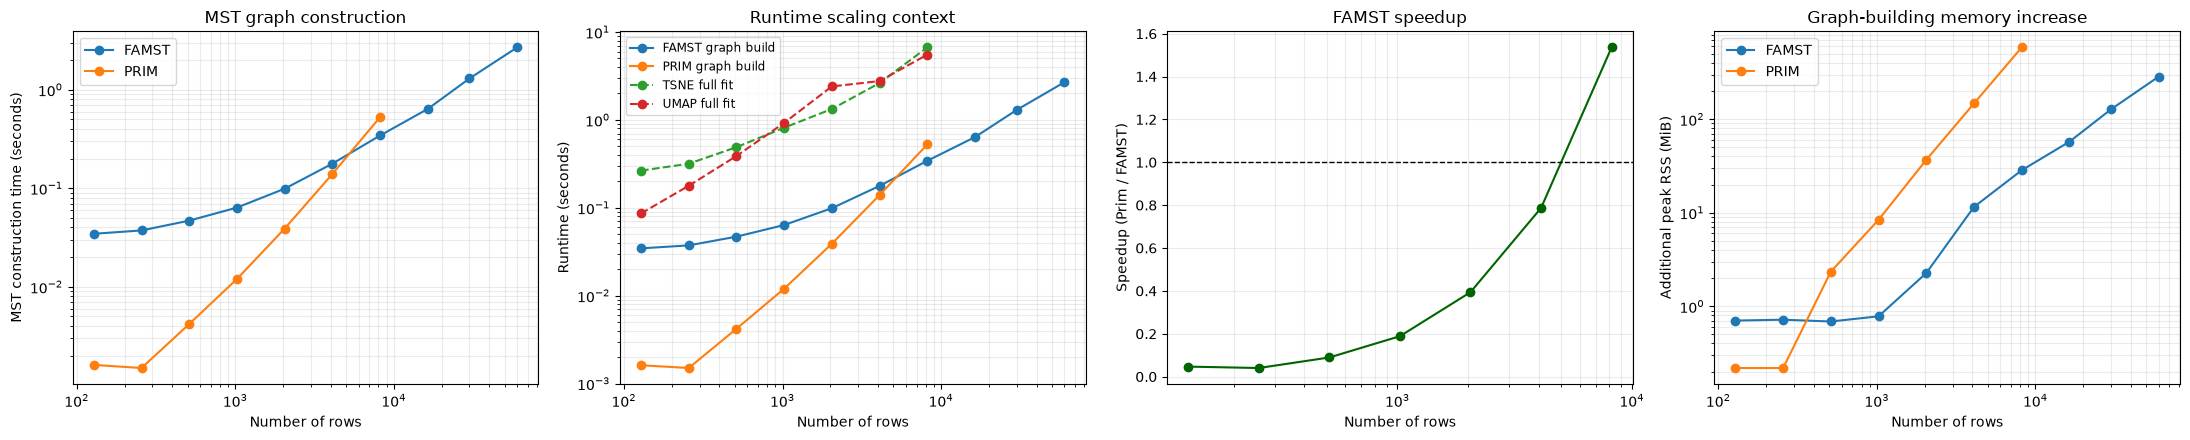

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))

for method, group in results.groupby('method'):
    axes[0].plot(
        group['n_samples'], group['median_seconds'],
        marker='o', label=method.upper(),
    )
axes[0].set(xscale='log', yscale='log', xlabel='Number of rows',
            ylabel='MST construction time (seconds)',
            title='MST graph construction')
axes[0].grid(True, which='both', alpha=0.25)
axes[0].legend()

for method, group in results.groupby('method'):
    axes[1].plot(
        group['n_samples'], group['median_seconds'],
        marker='o', label=f'{method.upper()} graph build',
    )
for method, group in embedding_results.groupby('method'):
    axes[1].plot(
        group['n_samples'], group['median_seconds'],
        marker='o', linestyle='--', label=f'{method.upper()} full fit',
    )
axes[1].set(xscale='log', yscale='log', xlabel='Number of rows',
            ylabel='Runtime (seconds)', title='Runtime scaling context')
axes[1].grid(True, which='both', alpha=0.25)
axes[1].legend(fontsize='small')

available_speedups = summary['speedup_prim_over_famst'].dropna()
axes[2].plot(available_speedups.index, available_speedups,
             marker='o', color='darkgreen')
axes[2].axhline(1, color='black', linewidth=1, linestyle='--')
axes[2].set(xscale='log', xlabel='Number of rows',
            ylabel='Speedup (Prim / FAMST)', title='FAMST speedup')
axes[2].grid(True, which='both', alpha=0.25)
for method, group in memory_results.groupby('method'):
    axes[3].plot(group['n_samples'], group['peak_working_set_mb'],
                 marker='o', label=method.upper())
axes[3].set(xscale='log', yscale='log', xlabel='Number of rows',
            ylabel='Additional peak RSS (MiB)',
            title='Graph-building memory increase')
axes[3].grid(True, which='both', alpha=0.25)
axes[3].legend()
plt.tight_layout()
plt.show()

## Interpretation

- At small sizes, ANN indexing and component handling can outweigh the savings from avoiding a dense distance matrix.
- At larger sizes, FAMST should benefit from its sparse neighbor graph; the crossover point depends on data, dimensions, hardware, and ANN settings.
- t-SNE and UMAP timings are full embedding fits, while Prim/FAMST timings measure graph construction only; compare their scaling with that scope difference in mind.
- t-SNE and UMAP results stop at `EMBEDDING_MAX_SAMPLES`; increase the cap only when the added runtime is acceptable.
- If Prim is skipped, no speedup or exact weight-error value is reported for that size.
- The exact backend is the reference for this synthetic dataset. FAMST can have low total-weight error while still choosing different tree edges.